In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
##############PREDEFINED FUNTIONS(JUST RUN IT)#############

import math as _m
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import numpy as np
from PIL import Image
from torchvision import transforms
from diffusers import AutoencoderKL, DDPMScheduler
from accelerate import Accelerator
import timm
import os, math, random, logging
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
import json

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import functional as TF
import torchvision.utils as vutils
import matplotlib.pyplot as plt

from accelerate import Accelerator
from diffusers import DDPMScheduler, UNet2DConditionModel, AutoencoderKL

In [3]:
##############PREDEFINED FUNTIONS(JUST RUN IT)#############

import math as _m
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import numpy as np
from PIL import Image
from torchvision import transforms
from diffusers import AutoencoderKL, DDPMScheduler
from accelerate import Accelerator
import timm
import os, math, random, logging
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
import json

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import functional as TF
import torchvision.utils as vutils
import matplotlib.pyplot as plt

from accelerate import Accelerator
from diffusers import DDPMScheduler, UNet2DConditionModel, AutoencoderKL

class Transpose(nn.Module):
    def __init__(self, dim0, dim1):
        super().__init__()
        self.dim0 = dim0
        self.dim1 = dim1
    def forward(self, x):
        return x.transpose(self.dim0, self.dim1)

class PositionalEncoding2D(nn.Module):
    def __init__(self, num_patches, dim):
        super().__init__()
        self.register_buffer('pos_embed', self.build_sincos_encoding(num_patches, dim), persistent=False)
    def build_sincos_encoding(self, num_patches, dim):
        pe = torch.zeros(num_patches, dim)
        position = torch.arange(0, num_patches, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, dim, 2).float() * (-math.log(10000.0) / dim))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe.unsqueeze(0)  # [1, num_patches, dim]
    def forward(self, x):
        return x + self.pos_embed[:, :x.size(1), :]

class ResidualBlock2d(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim=None):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_channels)
        self.act1  = nn.SiLU()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.act2  = nn.SiLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.skip  = nn.Conv2d(in_channels, out_channels, 1) if in_channels!=out_channels else nn.Identity()
        if time_dim is not None:
            self.to_time = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, out_channels))
        else:
            self.to_time = None

    def forward(self, x, t_emb=None):
        h = self.conv1(self.act1(self.norm1(x)))
        if self.to_time is not None and t_emb is not None:
            # FiLM-like add
            h = h + self.to_time(t_emb)[:, :, None, None]
        h = self.conv2(self.act2(self.norm2(h)))
        return h + self.skip(x)

# -----------------------------
# Cond Encoder (your original for stage-1 tokens)
# -----------------------------
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels)
        )
        self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        return self.block(x) + self.skip(x)

class CondEncoder(nn.Module):
    def __init__(self, in_channels=4, out_channels=736, num_tokens=64):
        super().__init__()
        self.encoder = nn.Sequential(
            ResidualBlock(in_channels, 64), # [B, 64, 64, 64]
            nn.AvgPool2d(2), # [B, 64, 32, 32]
            ResidualBlock(64, 128),
            nn.AvgPool2d(2), # [B, 128, 16, 16]
            ResidualBlock(128, 256),
            nn.AvgPool2d(2), # [B, 256, 8, 8]
            nn.Conv2d(256, out_channels, kernel_size=1) # [B, 736, 8, 8]
        )
        self.proj = nn.Sequential(
            nn.Flatten(2),  # [B, 736, 64]
            Transpose(-1, -2),   # [B, 64, 736]
        )
        self.pos_embed = PositionalEncoding2D(num_patches=num_tokens, dim=out_channels)
        self.norm = nn.LayerNorm(out_channels)

    def forward(self, x):
        feat = self.encoder(x)          # [B, 736, 8, 8]
        tokens = self.proj(feat)        # [B, 64, 736]
        tokens = self.pos_embed(tokens) # [B, 64, 736]
        tokens = self.norm(tokens)
        return tokens

def _g(n, c):  # GroupNorm
    return _m.gcd(n, c) or 1
##First part of encoder trainer
class SinCosPos2D(nn.Module):
    def __init__(self, H=64, W=64):
        super().__init__()
        yy, xx = torch.meshgrid(
            torch.linspace(0, 1, H), torch.linspace(0, 1, W), indexing='ij'
        )
        pe = torch.stack([
            torch.sin(2*_m.pi*xx), torch.cos(2*_m.pi*xx),
            torch.sin(2*_m.pi*yy), torch.cos(2*_m.pi*yy)
        ], dim=0)  # [4,H,W]
        self.register_buffer("pe", pe.float(), persistent=False)

    def forward(self, B):
        return self.pe.unsqueeze(0).repeat(B, 1, 1, 1)  # [B,4,H,W]

class ResInceptionDilated(nn.Module):
    def __init__(self, ch, mid=None):
        super().__init__()
        mid = mid or ch // 2

        self.pre = nn.Sequential(
            nn.GroupNorm(_g(8, ch), ch),
            nn.SiLU()
        )
        self.reduce = nn.Conv2d(ch, mid, 1)

        self.b1 = nn.Conv2d(mid, mid, 3, padding=1, dilation=1, groups=1, bias=False)
        self.b2 = nn.Conv2d(mid, mid, 3, padding=2, dilation=2, groups=1, bias=False)
        self.b3 = nn.Conv2d(mid, mid, 3, padding=4, dilation=4, groups=1, bias=False)

        self.fuse = nn.Sequential(
            nn.GroupNorm(_g(8, mid*3), mid*3),
            nn.SiLU(),
            nn.Conv2d(mid*3, ch, 1)
        )

    def forward(self, x):
        h = self.pre(x)
        h = self.reduce(h)
        h1 = self.b1(h)
        h2 = self.b2(h)
        h3 = self.b3(h)
        h  = torch.cat([h1, h2, h3], dim=1)
        h  = self.fuse(h)
        return x + h

class UpStage(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv = nn.Conv2d(ch, ch, 3, padding=1)
        self.rb   = ResInceptionDilated(ch, mid=ch//2)
    def forward(self, x):
        x = self.up(x)
        x = self.conv(x)
        x = self.rb(x)
        return x

class LatentAdapter(nn.Module):

    def __init__(self, cz=4, cond_ch=64, width=128,
                 num_blocks_64=3, include_posenc=True):
        super().__init__()
        self.include_posenc = include_posenc

        in_ch = cz + 4

        # 64×64
        self.in_conv = nn.Sequential(
            nn.Conv2d(in_ch, width, 3, padding=1),
            nn.GroupNorm(_g(8, width), width),
            nn.SiLU()
        )
        # 64×64
        self.blocks64 = nn.Sequential(*[ResInceptionDilated(width, mid=width//2) for _ in range(num_blocks_64)])


        self.up1 = UpStage(width)   # -> 128
        self.up2 = UpStage(width)   # -> 256
        self.up3 = UpStage(width)   # -> 512

        def head():
            return nn.Sequential(
                nn.Conv2d(width, cond_ch, 1),
                nn.GroupNorm(_g(8, cond_ch), cond_ch),
                nn.SiLU()
            )
        self.out64  = head()
        self.out128 = head()
        self.out256 = head()
        self.out512 = head()

        self.posenc = SinCosPos2D(64, 64) if include_posenc else None

    def forward(self, z64):
        """
        z64:    [B,4,64,64]
        mask64: [B,1,64,64] or None
        """
        B, _, H, W = z64.shape
        feats = [z64]


        if self.include_posenc:
            feats.append(self.posenc(B).to(z64.dtype).to(z64.device))

        x = torch.cat(feats, dim=1)             # [B,in_ch,64,64]
        x = self.in_conv(x)                     # [B,width,64,64]
        x = self.blocks64(x)

        f64  = self.out64(x)                    # [B,cond_ch,64,64]
        x128 = self.up1(x)
        f128 = self.out128(x128)                # [B,cond_ch,128,128]
        x256 = self.up2(x128)
        f256 = self.out256(x256)                # [B,cond_ch,256,256]
        x512 = self.up3(x256)
        f512 = self.out512(x512)                # [B,cond_ch,512,512]

        return {"s64": f64, "s128": f128, "s256": f256, "s512": f512}

class PrecomputedCascadeDataset(Dataset):
    def __init__(self, index_jsonl):
        self.items = []
        with open(index_jsonl, "r") as f:
            for line in f:
                path = json.loads(line)["pt"]
                if os.path.exists(path):
                    self.items.append(path)
                else:
                    print(f"[WARN] Missing file, skipped: {path}")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        pack = torch.load(self.items[i], map_location="cpu")
        return (
            pack["masked_img"].float(),     # [-1,1]
            pack["target_img"].float(),     # [-1,1]
            torch.tensor(pack["bbox"], dtype=torch.float32),
            pack["z_cond"].to(torch.float16)  # [4,64,64]
        )


def timestep_embedding(timesteps, dim, max_period=10000):
    half = dim // 2
    freqs = torch.exp(
        -math.log(max_period) * torch.arange(0, half, dtype=torch.float32, device=timesteps.device) / half
    )
    args = timesteps.float()[:, None] * freqs[None]
    emb = torch.cat([torch.cos(args), torch.sin(args)], dim=1)
    if dim % 2:
        emb = torch.cat([emb, emb[:, :1]], dim=1)
    return emb


class Down(nn.Module):
    def __init__(self, in_ch, out_ch, tdim, cond_ch=0):
        super().__init__()
        self.block1 = ResidualBlock2d(in_ch + cond_ch, out_ch, time_dim=tdim)
        self.block2 = ResidualBlock2d(out_ch, out_ch, time_dim=tdim)
        self.down = nn.AvgPool2d(2)

    def forward(self, x, t_emb, cond=None):
        if cond is not None:
            x = torch.cat([x, cond], dim=1)
        x = self.block1(x, t_emb)
        x = self.block2(x, t_emb)
        x_down = self.down(x)
        return x, x_down  # return skip, next


class Up(nn.Module):
    def __init__(self, in_ch, out_ch, tdim, cond_ch=0):
        super().__init__()
        self.block1 = ResidualBlock2d(in_ch + cond_ch, out_ch, time_dim=tdim)
        self.block2 = ResidualBlock2d(out_ch, out_ch, time_dim=tdim)

    def forward(self, x, skip, t_emb, cond=None):
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        if cond is not None:
            x = torch.cat([x, cond], dim=1)
        x = self.block1(x, t_emb)
        x = self.block2(x, t_emb)
        return x


from timm.models.vision_transformer import Attention as ViTAttention
import torch.nn as nn
import math as _m


def _g(n, c):  # GroupNorm
    return _m.gcd(n, c) or 1


class TimmAttn2D(nn.Module):
    def __init__(self, dim, num_heads=4, qkv_bias=True, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        self.norm = nn.GroupNorm(_g(8, dim), dim)
        self.attn = ViTAttention(
            dim=dim,
            num_heads=num_heads,
            qkv_bias=qkv_bias,
            attn_drop=attn_drop,
            proj_drop=proj_drop,
        )

    def forward(self, x):  # x: [B,C,H,W]
        B, C, H, W = x.shape
        x = self.norm(x)
        x = x.flatten(2).transpose(1, 2)   # [B, HW, C]
        x = self.attn(x)                   # [B, HW, C]
        x = x.transpose(1, 2).reshape(B, C, H, W)
        return x
##Begins diffusion decoder

class UNet512(nn.Module):
    def __init__(self, base_ch=128, cond_ch=64, time_dim=256):
        super().__init__()
        ch1, ch2, ch3 = base_ch, base_ch * 2, base_ch * 4

        self.time_mlp = nn.Sequential(
            nn.Linear(320, time_dim), nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        # condition
        self.in_conv = nn.Conv2d(3 + cond_ch, ch1, 3, padding=1)

        # 512->256->128->64
        self.down1 = Down(ch1, ch1, tdim=time_dim, cond_ch=0)           # 512->256
        self.down2 = Down(ch1, ch2, tdim=time_dim, cond_ch=cond_ch)     # 256->128
        self.down3 = Down(ch2, ch3, tdim=time_dim, cond_ch=cond_ch)     # 128->64

        # 64×64
        self.attn64 = TimmAttn2D(dim=ch3, num_heads=4)

        # 64×64
        self.mid1 = ResidualBlock2d(ch3 + cond_ch, ch3, time_dim=time_dim)
        self.mid2 = ResidualBlock2d(ch3, ch3, time_dim=time_dim)

        # 64->128->256->512
        self.up3 = Up(ch3 + ch3, ch2, tdim=time_dim, cond_ch=cond_ch)
        self.up2 = Up(ch2 + ch2, ch1, tdim=time_dim, cond_ch=cond_ch)
        self.up1 = Up(ch1 + ch1, ch1, tdim=time_dim, cond_ch=0)

        self.out_norm = nn.GroupNorm(8, ch1)
        self.out = nn.Conv2d(ch1, 3, 3, padding=1)

    def forward(self, x, timesteps, cond_feats):
        # t embedding
        t_emb = self.time_mlp(timestep_embedding(timesteps, 320))

        x = torch.cat([x, cond_feats["s512"]], dim=1)
        x = self.in_conv(x)

        # Down: 512->256->128->64
        skip1, x = self.down1(x, t_emb, cond=None)
        skip2, x = self.down2(x, t_emb, cond=cond_feats["s256"])
        skip3, x = self.down3(x, t_emb, cond=cond_feats["s128"])

        # 64×64
        x = self.attn64(x)
        x = torch.cat([x, cond_feats["s64"]], dim=1)
        x = self.mid1(x, t_emb)
        x = self.mid2(x, t_emb)

        # Up: 64->128->256->512
        x = self.up3(x, skip3, t_emb, cond=cond_feats["s128"])
        x = self.up2(x, skip2, t_emb, cond=cond_feats["s256"])
        x = self.up1(x, skip1, t_emb, cond=None)

        x = self.out(self.out_norm(x).clamp(-6, 6))
        x = torch.tanh(x)
        return x


from torchvision.models import vgg16
from torchvision.models.feature_extraction import create_feature_extractor
from diffusers import DDPMScheduler

class Cascade512Trainer:
    def __init__(self, train_index, val_index, bs=4, lr=1e-5):
        self.accelerator = Accelerator(mixed_precision="fp16")
        self.loss_history, self.val_loss_history = [], []

        self.train_loader = DataLoader(
            PrecomputedCascadeDataset(train_index),
            batch_size=bs, shuffle=True, num_workers=4, pin_memory=True
        )
        self.val_loader = DataLoader(
            PrecomputedCascadeDataset(val_index),
            batch_size=2, shuffle=False, num_workers=2, pin_memory=True
        )

        self.adapter = LatentAdapter(cz=4, cond_ch=96)
        self.unet512 = UNet512(base_ch=192, cond_ch=96, time_dim=256)

        self.optimizer = torch.optim.AdamW(
            list(self.adapter.parameters()) + list(self.unet512.parameters()),
            lr=lr, betas=(0.9, 0.999), weight_decay=1e-5
        )

        self.train_scheduler = DDPMScheduler.from_pretrained(
            "runwayml/stable-diffusion-v1-5", subfolder="scheduler"
        )
        self.train_scheduler.config.prediction_type = "sample"

        self.infer_scheduler = DDPMScheduler.from_pretrained(
            "runwayml/stable-diffusion-v1-5", subfolder="scheduler"
        )
        self.infer_scheduler.config.prediction_type = "sample"

        comps = [self.adapter, self.unet512, self.train_loader, self.val_loader, self.optimizer]
        self.adapter, self.unet512, self.train_loader, self.val_loader, self.optimizer = self.accelerator.prepare(*comps)

        self.vis_dir = "drive/MyDrive/vis_cascade"
        os.makedirs(self.vis_dir, exist_ok=True)

        vgg = vgg16(pretrained=True).features.eval()
        self.vgg = create_feature_extractor(vgg, return_nodes={"16": "feat"}).requires_grad_(False)

        comps = [self.adapter, self.unet512, self.train_loader, self.val_loader, self.optimizer, self.vgg]
        self.adapter, self.unet512, self.train_loader, self.val_loader, self.optimizer, self.vgg = self.accelerator.prepare(*comps)

    def _pixel_mask_from_bbox(self, bbox, img_shape):
        B, _, H, W = img_shape
        masks = torch.zeros(B, 1, H, W, device=self.accelerator.device)
        for i in range(B):
            x1, y1, x2, y2 = bbox[i]
            x1i, x2i = int(x1.item() * W), int(x2.item() * W)
            y1i, y2i = int(y1.item() * H), int(y2.item() * H)
            masks[i, :, y1i:y2i, x1i:x2i] = 1.0
        return masks

    def _step(self, batch, train=True):
        masked_imgs, target_imgs, bbox, z_cond = batch
        z_cond = z_cond.to(self.accelerator.device, dtype=torch.float16)
        cond_feats = self.adapter(z_cond)
        noise = torch.randn_like(target_imgs)
        timesteps = torch.randint(
            0, self.train_scheduler.config.num_train_timesteps,
            (target_imgs.shape[0],), device=target_imgs.device
        ).long()
        x_noisy = self.train_scheduler.add_noise(target_imgs, noise, timesteps)
        pixel_mask = self._pixel_mask_from_bbox(bbox, target_imgs.shape)
        x0_pred = self.unet512(x_noisy, timesteps, cond_feats)
        loss_mse = F.mse_loss(x0_pred, target_imgs)

        with torch.no_grad():
            target_01 = (target_imgs.clamp(-1, 1) + 1) / 2
        pred_01 = (x0_pred.clamp(-1, 1) + 1) / 2
        vgg_feat_pred = self.vgg(pred_01)["feat"]
        vgg_feat_target = self.vgg(target_01)["feat"]
        loss_vgg = F.l1_loss(vgg_feat_pred, vgg_feat_target)

        loss = 0.9 * loss_mse + 0.1 * loss_vgg

        if train:
            self.accelerator.backward(loss)
        return loss

    @torch.no_grad()
    def validate(self):
        self.unet512.eval(); self.adapter.eval()
        total, n = 0.0, 0
        for batch in tqdm(self.val_loader, desc="Validating"):
            loss = self._step(batch, train=False)
            total += loss.item(); n += 1
        return total / max(1, n)

    @torch.no_grad()
    def visualize_epoch(self, epoch_idx: int, max_batches: int = 1, steps_stage2: int = 50):
        self.unet512.eval(); self.adapter.eval()
        saved = 0; grids = []
        self.infer_scheduler.set_timesteps(steps_stage2, device=self.accelerator.device)
        for batch in self.val_loader:
            masked_imgs, target_imgs, bbox, z_cond = batch
            z_cond = z_cond.to(self.accelerator.device, dtype=torch.float16)
            cond_feats = self.adapter(z_cond)

            B, _, H, W = masked_imgs.shape
            x = torch.randn(B, 3, H, W, device=self.accelerator.device) * self.infer_scheduler.init_noise_sigma
            for t in self.infer_scheduler.timesteps:
                t_batch = torch.full((B,), int(t), device=self.accelerator.device, dtype=torch.long)
                x0_pred = self.unet512(x, t_batch, cond_feats)
                x = self.infer_scheduler.step(x0_pred, t, x).prev_sample  # DDIM deterministic

            pred = (x.clamp(-1, 1) + 1) / 2
            masked_vis = (masked_imgs.clamp(-1, 1) + 1) / 2
            target_vis = (target_imgs.clamp(-1, 1) + 1) / 2
            triplet = torch.cat([masked_vis, target_vis, pred], dim=0)
            grid = vutils.make_grid(triplet, nrow=B, padding=2)
            grids.append(grid); saved += 1
            if saved >= max_batches: break
        if grids:
            big = torch.cat(grids, dim=1) if len(grids) > 1 else grids[0]
            out_path = os.path.join(self.vis_dir, f"epoch_{epoch_idx:03d}.png")
            vutils.save_image(big, out_path)
            self.accelerator.print(f"[Visualize] Saved {out_path}")

    @torch.no_grad()
    def eval_composition_batch(self, ae_model, index, steps_stage2=50, save_dir="comp_eval"):
        self.unet512.eval(); self.adapter.eval()
        os.makedirs(save_dir, exist_ok=True)

        self.infer_scheduler.set_timesteps(steps_stage2, device=self.accelerator.device)

        batch = next(iter(self.val_loader))
        masked_imgs, target_imgs, bbox, z_cond = batch
        B = masked_imgs.size(0)

        z_cond = z_cond.to(self.accelerator.device, dtype=torch.float16)
        cond_feats = self.adapter(z_cond)

        x = torch.randn(B, 3, masked_imgs.shape[2], masked_imgs.shape[3],
                        device=self.accelerator.device) * self.infer_scheduler.init_noise_sigma
        for t in self.infer_scheduler.timesteps:
            t_batch = torch.full((B,), int(t), device=self.accelerator.device, dtype=torch.long)
            x0_pred = self.unet512(x, t_batch, cond_feats)
            x = self.infer_scheduler.step(x0_pred, t, x).prev_sample

        pred_imgs = (x.clamp(-1, 1) + 1) / 2
        masked_vis = (masked_imgs.clamp(-1, 1) + 1) / 2
        target_vis = (target_imgs.clamp(-1, 1) + 1) / 2

        # composition
        fr_recon, fr_pred, fr_orig = [], [], []
        for i in range(B):
            type_recon = infer_cell_map(masked_vis[i], ae_model)
            type_pred = infer_cell_map(pred_imgs[i], ae_model)
            type_orig = infer_cell_map(target_vis[i], ae_model)

            dist_recon = compute_type_distribution(type_recon.squeeze(0).cpu().numpy(), num_types=25)
            dist_pred = compute_type_distribution(type_pred.squeeze(0).cpu().numpy(), num_types=25)
            dist_orig = compute_type_distribution(type_orig.squeeze(0).cpu().numpy(), num_types=25)

            fr_recon.append(dist_recon)
            fr_pred.append(dist_pred)
            fr_orig.append(dist_orig)

        for i in range(B):
            fig, axes = plt.subplots(3, 3, figsize=(12, 8))
            def show_img(ax, img, title):
                ax.imshow(img.permute(1, 2, 0).cpu().numpy())
                ax.set_title(title)
                ax.axis("off")

            show_img(axes[0, 0], masked_vis[i], "Recon (cond)")
            show_img(axes[0, 1], target_vis[i], "Orig (GT)")
            show_img(axes[0, 2], pred_imgs[i], "Pred")

            xs = np.arange(25)
            bar_width = 0.8
            for ax, frac, title in zip(
                axes[1],
                [fr_recon[i], fr_orig[i], fr_pred[i]],
                ["Recon comp", "Orig comp", "Pred comp"]
            ):
                ax.bar(xs, frac, width=bar_width, color="skyblue")
                ax.set_title(title)
                ax.set_ylim(0, 1)
                ax.set_xticks(xs)
                ax.set_xticklabels([f"T{i+1}" for i in xs], rotation=90, fontsize=6)
                ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
                ax.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
                ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.3)

            for ax, img, title in zip(
                axes[2],
                [masked_vis[i], target_vis[i], pred_imgs[i]],
                ["Recon RGB Hist", "Orig RGB Hist", "Pred RGB Hist"]
            ):
                img_np = img.cpu().numpy()
                colors = ["r", "g", "b"]
                for c in range(3):
                    hist, bins = np.histogram(img_np[c], bins=50, range=(0, 1))
                    ax.plot(bins[:-1], hist, color=colors[c], alpha=0.7, label=colors[c].upper())
                ax.set_title(title)
                ax.set_xlim(0, 1)
                ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
                ax.set_yticks([])
                ax.legend()

            plt.tight_layout()
            out_path = os.path.join(save_dir, f"vis_comp_img{i}_{index}.png")
            plt.savefig(out_path, dpi=150)
            plt.close()
            self.accelerator.print(f"[CompEval] Saved {out_path}")

    def train(self, epochs=30, patience=5, vis_steps_stage2=50):
        device = self.accelerator.device
        ae = Autoencoder().to(device).eval()
        ae.load_state_dict(torch.load("drive/MyDrive/newae2.pth", map_location=device))
        best = float("inf"); bad = 0
        for ep in range(1, epochs + 1):
            self.unet512.train(); self.adapter.train()
            prog = tqdm(self.train_loader, desc=f"Epoch {ep} [Train]")
            losses = []
            for batch in prog:
                with self.accelerator.accumulate(self.unet512):
                    loss = self._step(batch, train=True)
                    if self.accelerator.sync_gradients:
                        self.accelerator.clip_grad_norm_(self.unet512.parameters(), 1.0)
                    self.optimizer.step(); self.optimizer.zero_grad()
                losses.append(loss.item()); prog.set_postfix(loss=np.mean(losses))

            tr = float(np.mean(losses)); self.loss_history.append(tr)
            va = self.validate(); self.val_loss_history.append(va)
            self.accelerator.print(f"[Epoch {ep}] train={tr:.4f} val={va:.4f}")
            self.visualize_epoch(epoch_idx=ep, max_batches=4, steps_stage2=vis_steps_stage2)
            self.eval_composition_batch(ae, ep, steps_stage2=vis_steps_stage2,
                                        save_dir="drive/MyDrive/checkpoint_cascade512_best1")

            if va < 1:
                best = va; bad = 0
                self.accelerator.wait_for_everyone()
                self.accelerator.save_state("drive/MyDrive/checkpoint_cascade512_best1")
                self.accelerator.print(f"  >> Saved best at val {best:.4f}")
            else:
                bad += 1; self.accelerator.print(f"  >> No improve ({bad}/{patience})")
                if bad >= patience:
                    self.accelerator.print("Early stop."); break

In [4]:
class Autoencoder(nn.Module):
    def __init__(self, in_dim=25, bottleneck_dim=3, hidden_dim=512):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, int(hidden_dim/4)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/4)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/4), int(hidden_dim/2)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/2)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/2), int(hidden_dim)), nn.ReLU(), nn.LayerNorm(int(hidden_dim)), nn.Dropout(0.1),
            nn.Linear(hidden_dim, int(hidden_dim/2)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/2)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/2), int(hidden_dim/4)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/4)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/4), bottleneck_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, int(hidden_dim/4)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/4)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/4), int(hidden_dim/2)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/2)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/2), hidden_dim), nn.ReLU(), nn.LayerNorm(int(hidden_dim)), nn.Dropout(0.1),
            nn.Linear(hidden_dim, int(hidden_dim/2)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/2)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/2), int(hidden_dim/4)), nn.ReLU(), nn.LayerNorm(int(hidden_dim/4)), nn.Dropout(0.1),
            nn.Linear(int(hidden_dim/4), in_dim),
        )
    def forward(self, x):
        z = self.encoder(x)
        return z, self.decoder(z)

_MIN_VALS = torch.tensor([-69.761505, -75.65188, -77.16103], dtype=torch.float32)
_MAX_VALS = torch.tensor([ 88.969406,  65.244896, 67.13518 ], dtype=torch.float32)
_RANGE    = _MAX_VALS - _MIN_VALS
THRESH_WHITE_01 = 250.0/255.0

@torch.no_grad()
def fractions_from_batch_rgb(imgs_m11, ae_model):
    device = next(ae_model.parameters()).device
    B, _, H, W = imgs_m11.shape
    x01 = imgs_m11
    mv = _MIN_VALS.to(device); rg = _RANGE.to(device); thr = THRESH_WHITE_01

    fracs = []; pixs = []
    for i in range(B):
        rgb = x01[i].to(device)                        # [3,H,W]
        flat = rgb.permute(1,2,0).reshape(-1,3)
        white = ((flat > thr)).all(dim=1)
        valid = flat[~white]
        if valid.numel() == 0:
            fracs.append(torch.zeros(25, device="cpu")); pixs.append(0); continue
        z = valid * rg + mv
        logits = ae_model.decoder(z)                   # [N,25]
        pred = torch.argmax(logits, dim=1)             # 0..24
        cnt  = torch.bincount(pred, minlength=25).float().cpu()
        fracs.append(cnt / cnt.sum().clamp_min(1))
        pixs.append(int(cnt.sum().item()))
    return torch.stack(fracs, 0), np.array(pixs, dtype=np.int64)

In [12]:
DEVICE = torch.device("cuda")
ae_model = Autoencoder().to(DEVICE).eval()
ae_model.load_state_dict(torch.load("drive/MyDrive/newae2.pth", map_location="cpu"))
ae_model.to(DEVICE)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=25, out_features=128, bias=True)
    (1): ReLU()
    (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): ReLU()
    (6): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=256, out_features=512, bias=True)
    (9): ReLU()
    (10): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=512, out_features=256, bias=True)
    (13): ReLU()
    (14): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (15): Dropout(p=0.1, inplace=False)
    (16): Linear(in_features=256, out_features=128, bias=True)
    (17): ReLU()
    (18): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (19): Dropout(p=0.1, inplace=False)
    (20): Linear(in_features=128, out_features=3, bia

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from collections import defaultdict
import torch
import json, os, re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.spatial.distance import jensenshannon


def compute_jsd(p, q):
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)
    p /= p.sum(); q /= q.sum()
    return jensenshannon(p, q, base=2) ** 2

def load_and_recover_z3d_png(path):
    """
    Load a PNG image as RGB, interpret it as normalized z_3d embedding encoded as uint8 [0–255],
    and recover the original z_3d float values via inverse scaling.
    """
    # 1. Load RGB image as uint8 tensor
    img = Image.open(path).convert("RGB")
    arr = torch.ByteTensor(torch.ByteStorage.from_buffer(img.tobytes()))
    rgb = arr.view(img.size[1], img.size[0], 3).permute(2, 0, 1).clone()  # [3, H, W], uint8
    mask = (rgb > 230).all(dim=0)
    rgb[:, mask] = 255
    rgb_float = rgb.float() / 255.0  # [3, H, W], float32
    non_white_pixels = ((rgb_float != 1).any(dim=0)).sum().item()
    print(f"count for non white: {non_white_pixels}")

    return rgb_float

def infer_cell_map(latent_image, model):
    min_vals = torch.tensor([-69.761505, -75.65188,  -77.16103], device=latent_image.device)
    range_vals = torch.tensor([88.969406, 65.244896, 67.13518], device=latent_image.device) - min_vals
    H, W = latent_image.shape[1], latent_image.shape[2]
    latent_image = latent_image.to("cuda")
    range_vals = range_vals.to("cuda")
    min_vals = min_vals.to("cuda")

    print("Original RGB min/max：")
    print("  R:", latent_image[0].min().item(), latent_image[0].max().item())
    print("  G:", latent_image[1].min().item(), latent_image[1].max().item())
    print("  B:", latent_image[2].min().item(), latent_image[2].max().item())

    flat_img = latent_image.permute(1, 2, 0).reshape(-1, 3)
    white_mask = (flat_img > 0.95).all(dim=1)

    print("valid pixel：", (~white_mask).sum().item())

    infer_input_rgb = flat_img[~white_mask]
    pred = torch.zeros(flat_img.shape[0], dtype=torch.long, device="cuda")
    if infer_input_rgb.shape[0] > 0:
        z_recovered = infer_input_rgb * range_vals + min_vals
        logits = model.decoder(z_recovered)
        pred[~white_mask] = torch.argmax(logits, dim=1) + 1

    pred = pred.reshape(1, H, W)
    return pred


device = "cuda"

cell_type_names = [
    "B", "CD4+ T cell", "CD57+ Enterocyte", "CD66+ Enterocyte", "CD7+ Immune",
    "CD8+ T", "Cycling TA", "DC", "Endothelial", "Enterocyte",
    "Goblet", "ICC", "Lymphatic", "M1 Macrophage", "M2 Macrophage",
    "MUC1+ Enterocyte", "NK", "Nerve", "Neuroendocrine", "Neutrophil",
    "Paneth", "Plasma", "Smooth muscle", "Stroma", "TA"
]

type_color_dict = {
    1: [134.9, 124.1, 8.7],
    2: [62.3, 216.0, 132.0],
    3: [130.9, 46.4, 182.5],
    4: [92.8, 63.6, 202.5],
    5: [140.1, 239.7, 189.0],
    6: [200.0, 183.1, 168.9],
    7: [108.3, 16.1, 142.3],
    8: [132.7, 217.1, 223.4],
    9: [170.6, 96.0, 98.0],
    10: [68.4, 101.1, 101.3],
    11: [4.6, 146.9, 145.6],
    12: [177.1, 1.5, 112.2],
    13: [202.6, 136.4, 12.3],
    14: [95.1, 244.3, 209.6],
    15: [32.5, 214.2, 217.8],
    16: [176.2, 78.6, 193.2],
    17: [185.9, 206.0, 77.8],
    18: [212.0, 39.3, 35.0],
    19: [117.1, 190.4, 53.4],
    20: [101.2, 145.2, 246.9],
    21: [13.7, 179.1, 133.2],
    22: [247.4, 125.5, 111.5],
    23: [122.9, 151.0, 150.0],
    24: [118.0, 45.6, 47.7],
    25: [31.1, 114.7, 222.5]
}

type_color_norm = {
    idx: (np.array(rgb) / 255.0).tolist() for idx, rgb in type_color_dict.items()
}

def compute_type_distribution(type_map_np: np.ndarray, num_types: int = 25) -> np.ndarray:
    counts = np.bincount(type_map_np.ravel(), minlength=num_types + 1)[1:num_types + 1].astype(float)
    total = counts.sum()
    if total <= 0:
        return np.zeros(num_types, dtype=float)
    return counts / total

def save_inferred_map_to_df(cell_type_map: torch.Tensor, region_id=0) -> pd.DataFrame:
    if cell_type_map.ndim == 3:
        cell_type_map = cell_type_map.squeeze(0)  # [H, W]
    cell_type_np = cell_type_map.detach().cpu().numpy()  # [H, W]
    ys, xs = np.where(cell_type_np > 0)
    types = cell_type_np[ys, xs].astype(int)
    df = pd.DataFrame({
        "Cell Type": [cell_type_names[t - 1] for t in types],
        "x": xs,
        "y": ys,
        "unique_region": region_id
    })
    return df


In [6]:
#######to get cell type distribution#########
def image_to_composition_distribution(image_tensor: torch.Tensor, ae_model: torch.nn.Module, num_types: int = 25) -> np.ndarray:
    """
    Convert an RGB image tensor to cell type composition distribution using the AE model.

    Args:
        image_tensor (torch.Tensor): Tensor of shape [3, H, W], values in [0, 1].
        ae_model (torch.nn.Module): Pretrained autoencoder model with a .decoder method.
        num_types (int): Number of target cell types (default: 25).

    Returns:
        np.ndarray: Normalized composition distribution, shape [25].
    """
    assert image_tensor.ndim == 3 and image_tensor.shape[0] == 3, "Expecting image tensor of shape [3, H, W]"
    image_tensor = image_tensor.to("cuda")

    # --- Print min/max for debug
    print("Image RGB min/max:")
    print("  R:", image_tensor[0].min().item(), image_tensor[0].max().item())
    print("  G:", image_tensor[1].min().item(), image_tensor[1].max().item())
    print("  B:", image_tensor[2].min().item(), image_tensor[2].max().item())

    # Constants to recover z from RGB
    min_vals = torch.tensor([-69.761505, -75.65188,  -77.16103], device="cuda")
    range_vals = torch.tensor([88.969406, 65.244896, 67.13518], device="cuda") - min_vals

    # Reshape
    H, W = image_tensor.shape[1], image_tensor.shape[2]
    flat_img = image_tensor.permute(1, 2, 0).reshape(-1, 3)

    # White mask (ignore white pixels)
    white_mask = (flat_img > 0.95).all(dim=1)
    print("Valid pixels:", (~white_mask).sum().item())

    # Inference
    pred = torch.zeros(flat_img.shape[0], dtype=torch.long, device="cuda")
    if (~white_mask).sum() > 0:
        infer_input_rgb = flat_img[~white_mask]
        z_recovered = infer_input_rgb * range_vals + min_vals
        logits = ae_model.decoder(z_recovered)
        pred[~white_mask] = torch.argmax(logits, dim=1) + 1  # [1,25]

    # Convert to map and compute distribution
    pred_map = pred.reshape(1, H, W)
    comp = compute_type_distribution(pred_map.squeeze(0).cpu().numpy(), num_types=num_types)
    return comp


In [ ]:
## TODO
##GAP FILLER DECODING

In [7]:
import os
import torch
from PIL import Image
from torchvision import transforms
from diffusers import DDPMScheduler
from accelerate import Accelerator

from google.colab import drive
drive.mount('/content/drive')

# -------------------- PATHS --------------------
latent_dir = "/content/drive/MyDrive/inpaint_bootstrap/region_39/"  # <— flat folder of .pt files
save_dir   = "/content/drive/MyDrive/inpaint_bootstrap/region_39/results/"
ckpt_path  = "/content/drive/MyDrive/checkpoint_cascade512_best1"  # accelerate checkpoint dir/file
scheduler_model_id = "runwayml/stable-diffusion-v1-5"

os.makedirs(save_dir, exist_ok=True)

# -------------------- DEVICE / MODELS --------------------

device = torch.device("cuda")
accelerator = Accelerator(mixed_precision="fp16")

adapter = LatentAdapter(cz=4, cond_ch=96)
unet    = UNet512(base_ch=192, cond_ch=96, time_dim=256)

scheduler = DDPMScheduler.from_pretrained(scheduler_model_id, subfolder="scheduler")
scheduler.set_timesteps(50, device=device)
scheduler.config.prediction_type = "sample"

adapter, unet = accelerator.prepare(adapter, unet)
accelerator.load_state(ckpt_path)   # must match how you saved
adapter.eval(); unet.eval()

to_pil = transforms.ToPILImage()

# -------------------- HELPERS --------------------
def decoded_name_from_latent(latent_filename: str) -> str:
    """
    Map 'pair_..._latent.pt' -> 'pair_..._decoded.png'
    If it doesn't end with '_latent.pt', just append '_decoded.png'.
    """
    base = os.path.splitext(latent_filename)[0]  # strip .pt
    if base.endswith("_latent"):
        base = base[:-len("_latent")]
    return f"{base}_decoded.png"
#
# -------------------- MAIN LOOP --------------------
pt_files = sorted([f for f in os.listdir(latent_dir) if f.lower().endswith(".pt")])
if not pt_files:
    print(f"[ERROR] No .pt files found in {latent_dir}")
else:
    print(f"[INFO] Found {len(pt_files)} latent(s) in {latent_dir}")

for fname in pt_files:
    latent_path = os.path.join(latent_dir, fname)

    # ---- Load latent ----
    ckpt = torch.load(latent_path, map_location="cpu")

    # Pull tensor & scaling factor out of dict (or handle raw tensor)
    if isinstance(ckpt, dict):
        z = ckpt.get("blended_latent")
        scale = float(ckpt.get("vae_scaling_factor", 0.18215))  # SD default fallback
        if z is None:
            # try a couple common alternative keys if you ever changed names
            for k in ("latent", "latents", "z"):
                if k in ckpt:
                    z = ckpt[k]
                    break
            if z is None:
                raise ValueError(f"No latent tensor found in {latent_path}; keys={list(ckpt.keys())}")
    else:
        z = ckpt
        scale = 0.18215

    # Ensure shape [B,4,h,w]
    if z.ndim == 3:
        z = z.unsqueeze(0)
    elif z.ndim != 4:
        raise ValueError(f"Unexpected latent ndim={z.ndim} for {latent_path}")

    # Move to device / dtype
    z = z.to(accelerator.device, dtype=torch.float16)


    # ---- Diffusion decode ----
    with torch.no_grad():
        cond_feats = adapter(z)
        B, _, H, W = 1, 3, 512, 512
        x = torch.randn(B, 3, H, W, device=accelerator.device) * scheduler.init_noise_sigma

        for t in scheduler.timesteps:
            t_batch = torch.full((B,), int(t), device=accelerator.device, dtype=torch.long)
            x0_pred = unet(x, t_batch, cond_feats)
            x = scheduler.step(x0_pred, t, x).prev_sample

        out_img = (x.clamp(-1, 1) + 1) / 2  # [0,1], fp16

    # ---- Save PNG with matching pattern ----
    out_pil = to_pil(out_img[0].float().cpu())
    out_name = decoded_name_from_latent(fname)
    out_path = os.path.join(save_dir, out_name)
    out_pil.save(out_path)
    print(f"[Saved] {out_path}")

print("All latents decoded.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

[INFO] Found 20 latent(s) in /content/drive/MyDrive/inpaint_bootstrap/region_39/
[Saved] /content/drive/MyDrive/inpaint_bootstrap/region_39/results/region_39_samebox_10_decoded.png
[Saved] /content/drive/MyDrive/inpaint_bootstrap/region_39/results/region_39_samebox_11_decoded.png
[Saved] /content/drive/MyDrive/inpaint_bootstrap/region_39/results/region_39_samebox_12_decoded.png
[Saved] /content/drive/MyDrive/inpaint_bootstrap/region_39/results/region_39_samebox_13_decoded.png
[Saved] /content/drive/MyDrive/inpaint_bootstrap/region_39/results/region_39_samebox_14_decoded.png
[Saved] /content/drive/MyDrive/inpaint_bootstrap/region_39/results/region_39_samebox_15_decoded.png
[Saved] /content/drive/MyDrive/inpaint_bootstrap/region_39/results/region_39_samebox_16_decoded.png
[Saved] /content/drive/MyDrive/inpaint_bootstrap/region_39/results/region_39_samebox_17_decoded.png
[Saved] /content/drive/MyDrive/inpaint_bootstrap/region_39/results/region_39_samebox_18_decoded.png
[Saved] /content/dr

In [9]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from diffusers import AutoencoderKL, DDPMScheduler
from accelerate import Accelerator
from torchvision import transforms
from scipy.spatial.distance import jensenshannon

# ---------- Helper Functions ----------

def compute_jsd(p, q):
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)
    p /= p.sum(); q /= q.sum()
    return jensenshannon(p, q, base=2) ** 2

def compute_type_distribution(type_map_np, num_types=25):
    counts = np.bincount(type_map_np.ravel(), minlength=num_types + 1)[1:num_types + 1].astype(float)
    total = counts.sum()
    if total <= 0:
        return np.zeros(num_types, dtype=float)
    return counts / total

def infer_cell_map(latent_image, model):
    latent_image = latent_image.half().to("cuda")
    min_vals = torch.tensor([-69.761505, -75.65188,  -77.16103], device=latent_image.device)
    range_vals = torch.tensor([88.969406, 65.244896, 67.13518], device=latent_image.device) - min_vals
    H, W = latent_image.shape[1], latent_image.shape[2]
    flat_img = latent_image.permute(1, 2, 0).reshape(-1, 3)
    white_mask = (flat_img > 0.93).all(dim=1)
    infer_input_rgb = flat_img[~white_mask]
    pred = torch.zeros(flat_img.shape[0], dtype=torch.long, device="cuda")
    if infer_input_rgb.shape[0] > 0:
        z_recovered = infer_input_rgb * range_vals + min_vals
        logits = model.decoder(z_recovered)
        pred[~white_mask] = torch.argmax(logits, dim=1) + 1
    return pred.reshape(1, H, W)

# ---------- Main Function ----------

@torch.no_grad()
def decode_and_eval_patch_distributions(
    root_dir, save_dir,
    vae_path="runwayml/stable-diffusion-v1-5",
    ckpt_path="/content/drive/MyDrive/checkpoint_cascade512_best1",
    steps=100
):
    os.makedirs(save_dir, exist_ok=True)
    device = torch.device("cuda")
    accelerator = Accelerator(mixed_precision="fp16")

    # Load model
    adapter = LatentAdapter(cz=4, cond_ch=96)
    unet = UNet512(base_ch=192, cond_ch=96, time_dim=256)
    scheduler = DDPMScheduler.from_pretrained(vae_path, subfolder="scheduler")
    scheduler.set_timesteps(steps, device=device)
    scheduler.config.prediction_type = "sample"

    adapter, unet = accelerator.prepare(adapter, unet)
    accelerator.load_state(ckpt_path)
    adapter.eval(); unet.eval()

    ae_model = Autoencoder().to(device)
    ae_model.load_state_dict(torch.load("drive/MyDrive/newae2.pth", map_location=device))
    ae_model.eval()

    # Start processing regions
    region_dirs = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
    top_dists, bot_dists, region_names = [], [], []

    for region in tqdm(region_dirs, desc="Processing regions"):
        latent_path = os.path.join(root_dir, region, "4_latent.pt")
        if not os.path.exists(latent_path):
            continue

        z = torch.load(latent_path, map_location="cpu").to(device, dtype=torch.float16)
        if z.ndim == 3:
            z = z.unsqueeze(0)

        # Decode with diffusion
        cond_feats = adapter(z)
        B, _, H, W = 1, 3, 512, 512
        x = torch.randn(B, 3, H, W, device=device) * scheduler.init_noise_sigma
        for t in scheduler.timesteps:
            t_batch = torch.full((B,), int(t), device=device, dtype=torch.long)
            x0_pred = unet(x, t_batch, cond_feats)
            x = scheduler.step(x0_pred, t, x).prev_sample
        img = (x.clamp(-1, 1) + 1) / 2  # [1,3,H,W]

        img_top = img[0, :, :int(H * 0.3), :]
        img_bot = img[0, :, int(H * 0.3):, :]

        # --- Filter if top is too white
        flat_top = img_top.permute(1, 2, 0).reshape(-1, 3)
        white_mask = (flat_top > 0.93).all(dim=1)
        white_ratio = white_mask.float().mean().item()
        if white_ratio > 0.9:
            print(f"⚠️  Skipping {region} due to >90% white in top patch ({white_ratio:.2%})")
            continue

        # Inference
        type_top = infer_cell_map(img_top, model=ae_model)
        type_bot = infer_cell_map(img_bot, model=ae_model)

        dist_top = compute_type_distribution(type_top.squeeze(0).cpu().numpy(), num_types=25)
        dist_bot = compute_type_distribution(type_bot.squeeze(0).cpu().numpy(), num_types=25)

        top_dists.append(dist_top)
        bot_dists.append(dist_bot)
        region_names.append(region)

    # Build JSD matrices
    top_dists = np.stack(top_dists, axis=0)
    bot_dists = np.stack(bot_dists, axis=0)
    N = len(top_dists)

    top_jsd = np.zeros((N, N))
    bot_jsd = np.zeros((N, N))
    cross_jsd = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            top_jsd[i, j] = compute_jsd(top_dists[i], top_dists[j])
            bot_jsd[i, j] = compute_jsd(bot_dists[i], bot_dists[j])
            cross_jsd[i, j] = compute_jsd(top_dists[i], bot_dists[j])

    # Save heatmaps
    def plot_heatmap(mat, title, fname):
        plt.figure(figsize=(0.4 * N + 4, 0.4 * N + 4))
        sns.heatmap(mat, xticklabels=region_names, yticklabels=region_names,
                    cmap="plasma", annot=False, vmin=0, vmax=1)
        plt.title(title)
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, fname), dpi=200)
        plt.close()

    plot_heatmap(top_jsd, "Top Patch JSD", "jsd_top.png")
    plot_heatmap(bot_jsd, "Bottom Patch JSD", "jsd_bottom.png")
    plot_heatmap(cross_jsd, "Cross Patch JSD", "jsd_cross.png")

    print(f"[Done] Saved all heatmaps to {save_dir}")


In [10]:
import os
import re
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from diffusers import DDPMScheduler
from accelerate import Accelerator
from scipy.spatial.distance import jensenshannon

# ========= 工具函数 =========

def compute_jsd(p, q):
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)
    p /= p.sum(); q /= q.sum()
    return jensenshannon(p, q, base=2) ** 2

def compute_type_distribution(type_map_np, num_types=25):
    counts = np.bincount(type_map_np.ravel(), minlength=num_types + 1)[1:num_types + 1].astype(float)
    total = counts.sum()
    if total <= 0:
        return np.zeros(num_types, dtype=float)
    return counts / total

def infer_cell_map(latent_image, model):
    latent_image = latent_image.half().to("cuda")
    min_vals = torch.tensor([-69.761505, -75.65188,  -77.16103], device=latent_image.device)
    range_vals = torch.tensor([88.969406, 65.244896, 67.13518], device=latent_image.device) - min_vals
    H, W = latent_image.shape[1], latent_image.shape[2]
    flat_img = latent_image.permute(1, 2, 0).reshape(-1, 3)
    white_mask = (flat_img > 0.95).all(dim=1)
    infer_input_rgb = flat_img[~white_mask]
    pred = torch.zeros(flat_img.shape[0], dtype=torch.long, device=latent_image.device)
    if infer_input_rgb.shape[0] > 0:
        z_recovered = infer_input_rgb * range_vals + min_vals
        logits = model.decoder(z_recovered)
        pred[~white_mask] = torch.argmax(logits, dim=1) + 1
    return pred.reshape(1, H, W)

# ========= 主函数 =========

@torch.no_grad()
def decode_and_eval_patch_distributions(
    root_dir, save_dir, steps=100
):
    os.makedirs(save_dir, exist_ok=True)
    device = torch.device("cuda")
    # Load model
    accelerator = Accelerator(mixed_precision="fp16")
    adapter = LatentAdapter(cz=4, cond_ch=96)
    unet = UNet512(base_ch=192, cond_ch=96, time_dim=256)
    scheduler = DDPMScheduler.from_pretrained("runwayml/stable-diffusion-v1-5", subfolder="scheduler")
    scheduler.set_timesteps(steps, device=device)
    scheduler.config.prediction_type = "sample"

    adapter, unet = accelerator.prepare(adapter, unet)
    accelerator.load_state("/content/drive/MyDrive/checkpoint_cascade512_best1")
    adapter.eval(); unet.eval()

    ae_model = Autoencoder().to(device)
    ae_model.load_state_dict(torch.load("drive/MyDrive/newae2.pth", map_location=device))
    ae_model.eval()

    # Step 1. 读取 region 文件夹并按 prefix 分组
    region_dirs = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
    pattern = re.compile(r"^(\d+)\+(\d+)$")

    grouped = {}
    for d in region_dirs:
        match = pattern.match(d)
        if match:
            prefix = match.group(1)
            grouped.setdefault(prefix, []).append(d)

    print(f"Found {len(grouped)} prefix groups.")

    selected_regions = []  # 保存选中的 region
    top_dists, bot_dists, region_names = [], [], []

    for prefix, subdirs in tqdm(grouped.items(), desc="Selecting 1 sample per prefix"):
        subdirs = sorted(subdirs)
        found_valid = False

        for region in subdirs:
            latent_path = os.path.join(root_dir, region, "4_latent.pt")
            if not os.path.exists(latent_path):
                continue

            z = torch.load(latent_path, map_location="cpu").to(device, dtype=torch.float16)
            if z.ndim == 3:
                z = z.unsqueeze(0)

            # --- Diffusion decode ---
            cond_feats = adapter(z)
            B, _, H, W = 1, 3, 512, 512
            x = torch.randn(B, 3, H, W, device=device) * scheduler.init_noise_sigma
            for t in scheduler.timesteps:
                t_batch = torch.full((B,), int(t), device=device, dtype=torch.long)
                x0_pred = unet(x, t_batch, cond_feats)
                x = scheduler.step(x0_pred, t, x).prev_sample
            img = (x.clamp(-1, 1) + 1) / 2  # [1,3,H,W]

            # --- top/bottom split ---
            img_top = img[0, :, :int(H * 0.3), :]
            img_bot = img[0, :, int(H * 0.3):, :]

            # --- 白像素过滤 ---
            flat_top = img_top.permute(1, 2, 0).reshape(-1, 3)
            white_mask = (flat_top > 0.93).all(dim=1)
            white_ratio = white_mask.float().mean().item()
            if white_ratio > 0.9:
                print(f"⚠️  Skipping {region} due to >90% white top patch ({white_ratio:.2%})")
                continue

            # --- composition inference ---
            type_top = infer_cell_map(img_top, model=ae_model)
            type_bot = infer_cell_map(img_bot, model=ae_model)

            dist_top = compute_type_distribution(type_top.squeeze(0).cpu().numpy(), num_types=25)
            dist_bot = compute_type_distribution(type_bot.squeeze(0).cpu().numpy(), num_types=25)

            top_dists.append(dist_top)
            bot_dists.append(dist_bot)
            region_names.append(region)
            selected_regions.append(region)
            found_valid = True
            break  # ✅ 每个 prefix 只取一个样本

        if not found_valid:
            print(f"❌ No valid (non-white) sample found for prefix {prefix}")

    print(f"✅ Selected {len(selected_regions)} regions: {selected_regions}")

    # Step 2. 计算 Heatmap
    N = len(top_dists)
    top_dists = np.stack(top_dists, axis=0)
    bot_dists = np.stack(bot_dists, axis=0)

    top_jsd = np.zeros((N, N))
    bot_jsd = np.zeros((N, N))
    cross_jsd = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            top_jsd[i, j] = compute_jsd(top_dists[i], top_dists[j])
            bot_jsd[i, j] = compute_jsd(bot_dists[i], bot_dists[j])
            cross_jsd[i, j] = compute_jsd(top_dists[i], bot_dists[j])

    def plot_heatmap(mat, title, fname):
        plt.figure(figsize=(0.4 * N + 4, 0.4 * N + 4))
        sns.heatmap(mat, xticklabels=region_names, yticklabels=region_names,
                    cmap="plasma", annot=False, vmin=0, vmax=1)
        plt.title(title)
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, fname), dpi=200)
        plt.close()

    plot_heatmap(top_jsd, "Top Patch JSD", "jsd_top.png")
    plot_heatmap(bot_jsd, "Bottom Patch JSD", "jsd_bottom.png")
    plot_heatmap(cross_jsd, "Cross Patch JSD", "jsd_cross.png")

    print(f"🔥 Done. Saved all heatmaps to {save_dir}")


[INFO] Comparing 20 crops from: /content/drive/MyDrive/inpaint_bootstrap/region_39/results/


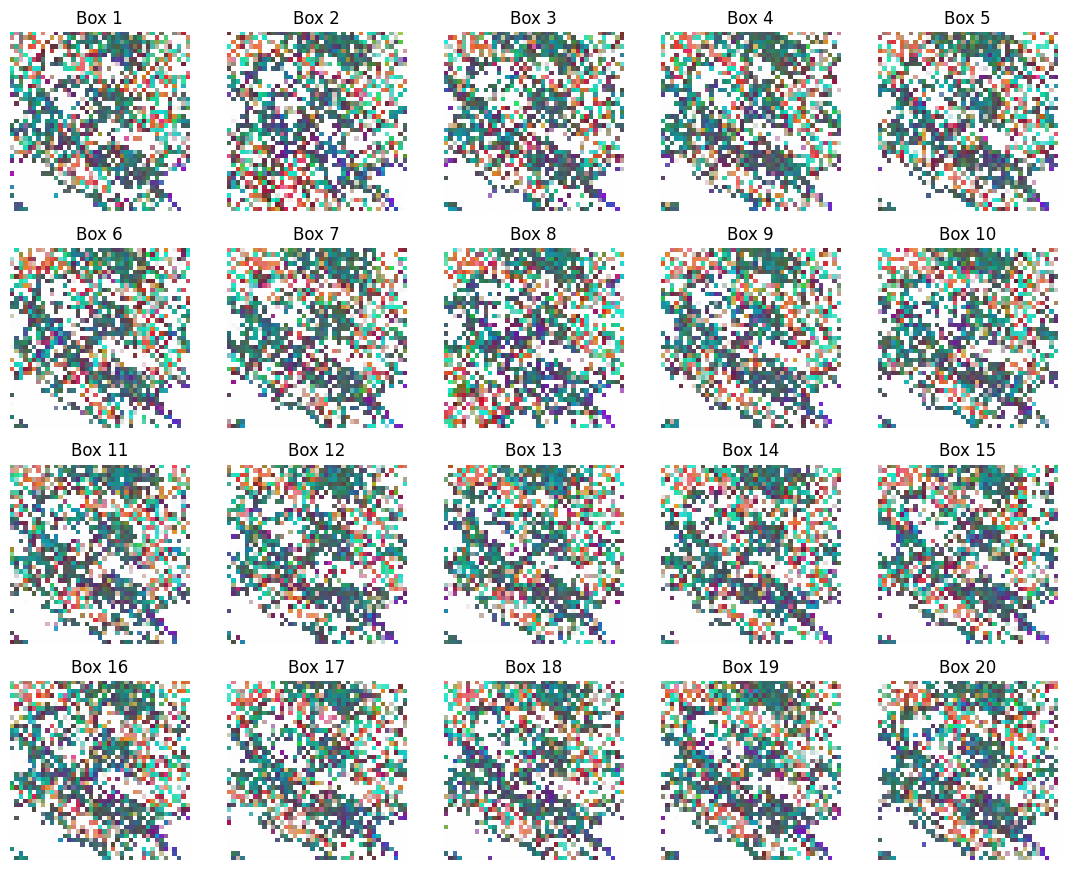

In [14]:
# =========================
# CROP & CELL-TYPE COMPARISON (same tiny box across 20 decoded images)
# =========================
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch

# ---- reuse your functions ----
# compute_jsd, compute_type_distribution, infer_cell_map must already be defined above

# ---- config ----
DECODED_DIR = save_dir  # <- where you saved *_decoded.png
bbox_norm_fixed = [0.36, 0.46, 0.44, 0.54]  # SAME box you used for inpainting (normalized [x1,y1,x2,y2])
NUM_BOXES = 20                               # compare first 20 decoded images
SHOW_PREVIEW_GRID = True                     # set False to skip preview
DEVICE = torch.device("cuda")

# If you have names for 25 cell types, list them here; otherwise make placeholders
cell_type_names = [f"Type{i}" for i in range(1, 26)]

# ---- gather decoded images ----
decoded_paths = sorted(glob.glob(os.path.join(DECODED_DIR, "*_decoded.png")))[:NUM_BOXES]
if len(decoded_paths) == 0:
    raise RuntimeError(f"No decoded PNGs found in {DECODED_DIR}")
print(f"[INFO] Comparing {len(decoded_paths)} crops from: {DECODED_DIR}")

# ---- helper: normalized crop ----
def crop_from_norm(img_pil: Image.Image, bbox_norm):
    W, H = img_pil.size
    x1 = int(bbox_norm[0] * W); y1 = int(bbox_norm[1] * H)
    x2 = int(bbox_norm[2] * W); y2 = int(bbox_norm[3] * H)
    # clamp
    x1 = max(0, min(x1, W)); x2 = max(0, min(x2, W))
    y1 = max(0, min(y1, H)); y2 = max(0, min(y2, H))
    if x2 <= x1 or y2 <= y1:
        raise ValueError(f"Invalid crop coords {(x1,y1,x2,y2)} for image {W}x{H}")
    return img_pil.crop((x1, y1, x2, y2)), (x1, y1, x2, y2)

# ---- collect crops ----
crops = []
boxes_px = []
for p in decoded_paths:
    img = Image.open(p).convert("RGB")
    crop, box_px = crop_from_norm(img, bbox_norm_fixed)
    crops.append(crop)
    boxes_px.append(box_px)

# ---- optional: preview the 20 tiny crops ----
if SHOW_PREVIEW_GRID:
    cols = 5
    rows = (len(crops) + cols - 1) // cols
    plt.figure(figsize=(cols*2.2, rows*2.2))
    for idx, crop in enumerate(crops, 1):
        ax = plt.subplot(rows, cols, idx)
        ax.imshow(crop)
        ax.set_title(f"Box {idx}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# ---- run cell-typing on each crop ----
# infer_cell_map expects a torch image [C,H,W] (0..1-ish), on CUDA fp16 in your code.
def crop_to_tensor_cuda_fp16(crop_pil: Image.Image) -> torch.Tensor:
    arr = np.asarray(crop_pil).astype(np.float32) / 255.0  # H,W,3 in [0,1]
    tens = torch.from_numpy(arr).permute(2, 0, 1).contiguous()  # [3,H,W]
    return tens.to(DEVICE).half()



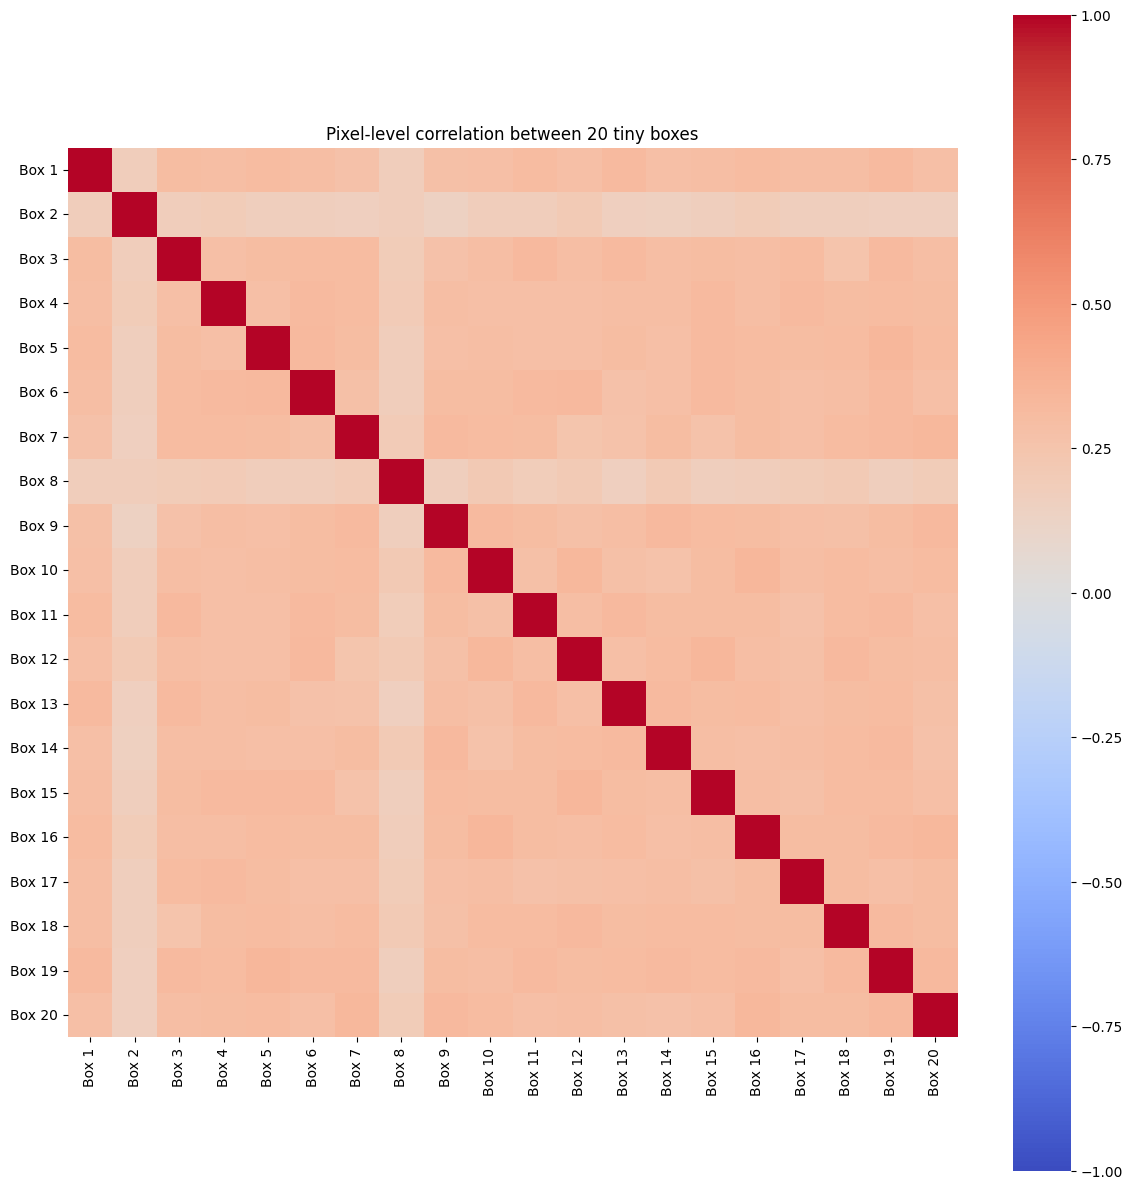

Mean correlation: 0.276


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---- convert all crops to numeric arrays [H*W*3] ----
crop_vecs = []
for crop in crops:
    arr = np.asarray(crop).astype(np.float32) / 255.0  # [H,W,3]
    crop_vecs.append(arr.reshape(-1, 3).flatten())      # [H*W*3]
crop_vecs = np.stack(crop_vecs, axis=0)                # [N, pixels*3]

# ---- compute correlation matrix ----
corr_mat = np.corrcoef(crop_vecs)                      # [N,N], Pearson correlation
N = corr_mat.shape[0]

# ---- plot correlation heatmap ----
plt.figure(figsize=(0.4*N + 4, 0.4*N + 4))
sns.heatmap(
    corr_mat, cmap="coolwarm", center=0, vmin=-1, vmax=1,
    square=True, xticklabels=[f"Box {i}" for i in range(1, N+1)],
    yticklabels=[f"Box {i}" for i in range(1, N+1)]
)
plt.title("Pixel-level correlation between 20 tiny boxes")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Mean correlation: {corr_mat[np.triu_indices(N, 1)].mean():.3f}")


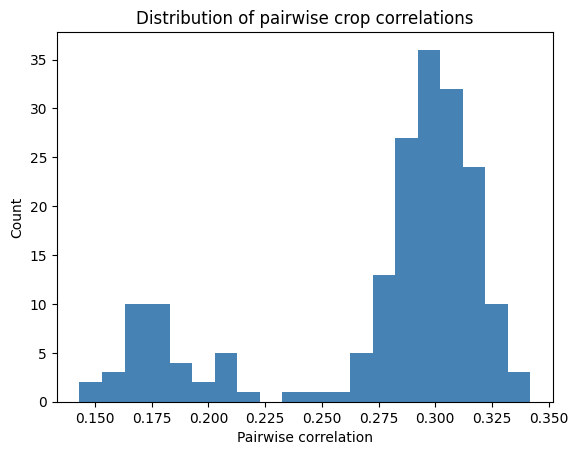

Same RGB pixels: 105 / 1,681  (6.246%)


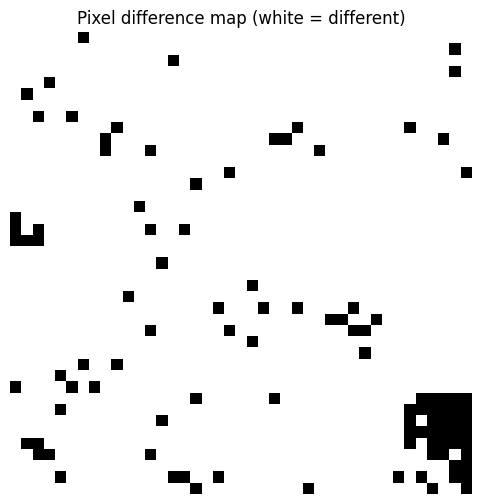

In [21]:
vals = corr_mat[np.triu_indices_from(corr_mat, k=1)]
plt.hist(vals, bins=20, color="steelblue"); plt.xlabel("Pairwise correlation"); plt.ylabel("Count");
plt.title("Distribution of pairwise crop correlations"); plt.show()
import numpy as np
from PIL import Image

# --- load the two crops (ensure same size!) ---
img1 = np.asarray(crops[0]).astype(np.uint8)
img2 = np.asarray(crops[1]).astype(np.uint8)
assert img1.shape == img2.shape, "Crops must be same size"

# --- compare pixels ---
same_mask = np.all(img1 == img2, axis=-1)     # True where R,G,B all match
num_same  = same_mask.sum()
total     = same_mask.size
fraction  = num_same / total

print(f"Same RGB pixels: {num_same:,} / {total:,}  ({fraction*100:.3f}%)")

# Optional: visualize difference map
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.imshow(~same_mask, cmap="gray")  # white = different
plt.title("Pixel difference map (white = different)")
plt.axis("off")
plt.show()


In [ ]:
# save_as: decode_gap_infer_and_heatmaps.py
import os
import re
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from diffusers import DDPMScheduler
from accelerate import Accelerator
from scipy.spatial.distance import jensenshannon
from torchvision import transforms
from PIL import Image
from pathlib import Path

# -------------------------
# User must provide/define/ import these:
#   LatentAdapter, UNet512, Autoencoder
#   - LatentAdapter: maps latent z_cond -> cond_feats for UNet512
#   - UNet512: your cascade unet (predicts x0)
#   - Autoencoder: your classifier/decoder with .decoder() used to infer cell types
# -------------------------
# from mymodels import LatentAdapter, UNet512, Autoencoder   # <-- replace with your import

# -------------------------
# Utility functions
# -------------------------
def compute_jsd(p, q):
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)
    # avoid zero-sum
    if p.sum() == 0:
        p = np.ones_like(p) / len(p)
    if q.sum() == 0:
        q = np.ones_like(q) / len(q)
    p /= p.sum(); q /= q.sum()
    return jensenshannon(p, q, base=2) ** 2

def compute_type_distribution(type_map_np, num_types=25):
    counts = np.bincount(type_map_np.ravel(), minlength=num_types + 1)[1:num_types + 1].astype(float)
    total = counts.sum()
    if total <= 0:
        return np.zeros(num_types, dtype=float)
    return counts / total

def infer_cell_map_local(img_rgb_01, classifier_model, device):
    """
    Infer cell map for a single patch.
    Args:
        img_rgb_01: torch.Tensor [3,H,W], values in [0,1], dtype can be float16/float32
        classifier_model: Autoencoder-like model with .decoder() that takes Nx3 z and outputs logits [N,25]
        device: device for classifier
    Returns:
        pred_map: torch.LongTensor shape [1,H,W] with values in {0..25} where 0 means background/white
    """
    # move & dtype safe: convert RGB in [0,1] -> float32 on classifier device
    img = img_rgb_01.to(device).float()  # [3,H,W]
    H, W = img.shape[1], img.shape[2]
    flat = img.permute(1,2,0).reshape(-1,3)  # [HW,3]
    white_mask = (flat > 0.93).all(dim=1)    # boolean mask
    valid = flat[~white_mask]                # [N_valid,3]
    pred = torch.zeros(flat.shape[0], dtype=torch.long, device=device)  # default 0 (background)
    if valid.shape[0] > 0:
        # convert from [0,1] RGB back to original z space expected by your classifier:
        # NOTE: this needs to match your earlier scaling: z = rgb * range + min
        min_vals = torch.tensor([-69.761505, -75.65188,  -77.16103], device=device, dtype=torch.float32)
        range_vals = (torch.tensor([88.969406, 65.244896, 67.13518], device=device, dtype=torch.float32)
                      - min_vals)
        z_recovered = valid * range_vals + min_vals  # [N_valid,3]
        logits = classifier_model.decoder(z_recovered)  # [N_valid, num_types]
        labels = torch.argmax(logits, dim=1).to(device) + 1  # 1..25
        pred[~white_mask] = labels
    pred_map = pred.reshape(1, H, W).cpu()
    return pred_map  # cpu LongTensor

# -------------------------
# Main processing function
# -------------------------
@torch.no_grad()
def decode_and_make_heatmaps(
    root_dir,
    save_dir,
    ckpt_path,
    steps=50,
    latent_name="/content/drive/MyDrive/20251006latent_eval/20251015GapFillerLatentPaths/pair_0_8_leftright_latent.pt",
    device=torch.device("cuda"),
    scheduler_model_id="runwayml/stable-diffusion-v1-5"
):
    os.makedirs(save_dir, exist_ok=True)

    # Accelerator & models
    accelerator = Accelerator(mixed_precision="fp16")
    adapter = LatentAdapter(cz=4, cond_ch=96)
    unet = UNet512(base_ch=192, cond_ch=96, time_dim=256)

    scheduler = DDPMScheduler.from_pretrained(scheduler_model_id, subfolder="scheduler")
    scheduler.set_timesteps(steps, device=device)
    scheduler.config.prediction_type = "sample"

    # Prepare + load checkpoint
    adapter, unet = accelerator.prepare(adapter, unet)
    accelerator.load_state(ckpt_path)  # assumes you saved with accelerate saving
    adapter.eval(); unet.eval()

    # load classifier autoencoder (decoder-based)
    ae_model = Autoencoder().to(device)
    ae_model.load_state_dict(torch.load("drive/MyDrive/newae2.pth", map_location=device))
    ae_model.eval()

    # locate subdirectories under root_dir (each subdir corresponds to an XXX)
    # ---------------- locate latent files robustly ----------------
    region_names = []
    latent_paths = []

    # Case 1: the latent is directly in root_dir (your situation)
    direct_path = os.path.join(root_dir, latent_name)
    if os.path.isfile(direct_path):
        latent_paths = [direct_path]
        region_names = [Path(root_dir).name]
    else:
        # Case 2: one-level subfolders named as regions
        subdirs = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        for name in subdirs:
            p = os.path.join(root_dir, name, latent_name)
            if os.path.isfile(p):
                latent_paths.append(p)
                region_names.append(name)

        # Case 3: fallback recursive search (any depth)
        if len(latent_paths) == 0:
            latent_paths = sorted(glob.glob(os.path.join(root_dir, "**", latent_name), recursive=True))
            region_names = [f"{Path(p).parent.name}/{Path(p).stem}" for p in latent_paths]

    if len(latent_paths) == 0:
        print(f"[ERROR] No latent files found under {root_dir} matching '{latent_name}'.")
        try:
            print("[DIR LIST]", os.listdir(root_dir)[:20])
        except Exception as e:
            print("[WARN] Could not list root_dir:", e)
        return

    print(f"[INFO] Found {len(latent_paths)} latent(s).")

    # We'll accumulate distributions
    left_dists = []
    mid_dists = []
    right_dists = []

    # ---------------- decode loop over discovered latents ----------------
    for latent_path, name in tqdm(list(zip(latent_paths, region_names)), desc="Decoding latents"):
        # load latent (CPU) then move to device/dtype expected by adapter/unet
        z = torch.load(latent_path, map_location="cpu")
        if z.ndim == 3:
            z = z.unsqueeze(0)
        z = z.to(accelerator.device, dtype=torch.float16)

        # diffusion decode -> image in [-1,1]
        cond_feats = adapter(z)
        B, _, H, W = 1, 3, 512, 512
        x = torch.randn(B, 3, H, W, device=accelerator.device) * scheduler.init_noise_sigma
        for t in scheduler.timesteps:
            t_batch = torch.full((B,), int(t), device=accelerator.device, dtype=torch.long)
            x0_pred = unet(x, t_batch, cond_feats)
            x = scheduler.step(x0_pred, t, x).prev_sample
        img01 = (x.clamp(-1, 1) + 1) / 2  # [1,3,H,W], in [0,1], dtype fp16

        # split left/mid/right (everything below here stays the same as your code)



        # split left/mid/right
        left_w = int(W * 0.125)
        right_w = left_w
        mid_w = W - left_w - right_w
        # slices: left: [:left_w], mid: [left_w:left_w+mid_w], right: [-right_w:]
        img = img01[0]  # [3,H,W]
        img_left = img[:, :, :left_w]
        img_mid  = img[:, :, left_w:left_w+mid_w]
        img_right= img[:, :, -right_w:]

        # compute white ratio on left; if >90% white, skip this sample (as requested earlier)
        flat_left = img_left.permute(1,2,0).reshape(-1,3)

        # infer cell maps (convert patches to classifier device inside)
        type_left = infer_cell_map_local(img_left, classifier_model=ae_model, device=device)   # [1,H_left,W_left] cpu
        type_mid  = infer_cell_map_local(img_mid, classifier_model=ae_model, device=device)
        type_right= infer_cell_map_local(img_right, classifier_model=ae_model, device=device)

        # compute distributions
        d_left  = compute_type_distribution(type_left.squeeze(0).numpy(), num_types=25)
        d_mid   = compute_type_distribution(type_mid.squeeze(0).numpy(), num_types=25)
        d_right = compute_type_distribution(type_right.squeeze(0).numpy(), num_types=25)

        left_dists.append(d_left)
        mid_dists.append(d_mid)
        right_dists.append(d_right)
        region_names.append(name)

        # Also save decoded full image for inspection
        out_img = (img01[0].detach().cpu().float().numpy().transpose(1,2,0) * 255).astype(np.uint8)
        Image.fromarray(out_img).save(os.path.join(save_dir, f"{name}_decoded.png"))

    # Convert lists -> arrays
    if len(region_names) == 0:
        print("[ERROR] No valid samples processed (maybe all skipped).")
        return

    left_arr  = np.stack(left_dists, axis=0)   # [N,25]
    mid_arr   = np.stack(mid_dists, axis=0)
    right_arr = np.stack(right_dists, axis=0)
    N = left_arr.shape[0]

    # Build heatmaps
    left_jsd = np.zeros((N,N))
    right_jsd= np.zeros((N,N))
    mid_vs_left = np.zeros((N,N))
    mid_vs_right = np.zeros((N,N))

    for i in range(N):
        for j in range(N):
            left_jsd[i,j] = compute_jsd(left_arr[i], left_arr[j])
            right_jsd[i,j]= compute_jsd(right_arr[i], right_arr[j])
            mid_vs_left[i,j] = compute_jsd(mid_arr[i], left_arr[j])
            mid_vs_right[i,j]= compute_jsd(mid_arr[i], right_arr[j])

    def plot_and_save_heatmap(mat, title, fname):
        plt.figure(figsize=(0.35 * max(10,N) + 4, 0.35 * max(10,N) + 4))
        sns.heatmap(mat, xticklabels=region_names, yticklabels=region_names,
                    cmap="plasma", annot=False, vmin=0, vmax=1)
        plt.title(title)
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        plt.tight_layout()
        outp = os.path.join(save_dir, fname)
        plt.savefig(outp, dpi=200)
        plt.close()
        print("[Saved]", outp)

    plot_and_save_heatmap(left_jsd, "Left 12.5% JSD (left vs left)", "heatmap_left_vs_left.png")
    plot_and_save_heatmap(right_jsd,"Right 12.5% JSD (right vs right)","heatmap_right_vs_right.png")
    plot_and_save_heatmap(mid_vs_left,"Mid vs Left JSD","heatmap_mid_vs_left.png")
    plot_and_save_heatmap(mid_vs_right,"Mid vs Right JSD","heatmap_mid_vs_right.png")

    # ---------------------------
    # Stacked bar: split each full decoded image into 8 vertical stripes and compute composition
    # ---------------------------
    stripes_save_dir = os.path.join(save_dir, "stripes_barcharts")
    os.makedirs(stripes_save_dir, exist_ok=True)

    # For each processed region, reload the decoded image and compute 8 stripes
    for idx, name in enumerate(region_names):
        decoded_path = os.path.join(save_dir, f"{name}_decoded.png")
        if not os.path.exists(decoded_path):
            continue
        pil = Image.open(decoded_path).convert("RGB")
        W = pil.width; H = pil.height
        stripe_w = W // 8
        stripe_fracs = []
        for s in range(8):
            x1 = s * stripe_w
            x2 = W if s == 7 else (s+1) * stripe_w
            crop = pil.crop((x1, 0, x2, H))
            t = transforms.ToTensor()(crop).to(device).unsqueeze(0)  # [1,3,H_s,W_s] in [0,1]
            # use infer_cell_map_local on each stripe
            patch = t[0]  # [3,H_s,W_s]
            type_map = infer_cell_map_local(patch, classifier_model=ae_model, device=device)  # [1,H_s,W_s]
            frac = compute_type_distribution(type_map.squeeze(0).cpu().numpy(), num_types=25)
            stripe_fracs.append(frac)

        stripe_fracs = np.stack(stripe_fracs, axis=0)  # [8,25]
        # Plot stacked bar
        fig, ax = plt.subplots(1,1,figsize=(10,5))
        x = np.arange(8)
        bottom = np.zeros(8)
        cmap = plt.get_cmap("tab20")
        for k in range(25):
            vals = stripe_fracs[:,k]
            ax.bar(x, vals, bottom=bottom, label=f"T{k+1}", color=cmap(k % 20))
            bottom += vals
        ax.set_xlabel("Stripe (left->right, 8 total)")
        ax.set_ylabel("Fraction")
        ax.set_title(f"Region {name} - 8-stripe cell composition")
        ax.set_xticks(x)
        ax.set_xticklabels([f"S{i+1}" for i in range(8)])
        ax.set_ylim(0,1)
        ax.legend(bbox_to_anchor=(1.02,1), loc="upper left", ncol=1, fontsize=6)
        plt.tight_layout()
        outf = os.path.join(stripes_save_dir, f"{name}_8stripe_composition.png")
        plt.savefig(outf, dpi=200)
        plt.close()
        print("[Saved stripe chart]", outf)

    print("All done. Heatmaps + stripe charts saved to:", save_dir)
    return {
        "region_names": region_names,
        "left_jsd": left_jsd,
        "right_jsd": right_jsd,
        "mid_vs_left": mid_vs_left,
        "mid_vs_right": mid_vs_right
    }


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

result = decode_and_make_heatmaps(
     root_dir="/content/drive/MyDrive/DISCO_USECASES/20251017GapFillerColorGuidedLatents/",
     save_dir="/content/drive/MyDrive/20251015_decoded_colorguide/20251017AllDecodedGapFillerColorGuide/results/",
     ckpt_path="/content/drive/MyDrive/checkpoint_cascade512_best1",
     steps=150,
     latent_name="pair_0_8_leftright_latent.pt",
     device=torch.device("cuda")
 )

## To get CSV files for x,y,cell_type for each region after having been passed through the encoder and decoder.

In [ ]:
# === Region PNG -> CSVs via your AE + infer_cell_map ===
import os, glob
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torchvision import transforms

# ---- Paths ----
PNG_DIR  = "/content/drive/MyDrive/202509CURRENT_Diff_TRAIN_set"   # region_*.png live here
SAVE_DIR = "/content/decoded_regions_csv"                          # where CSVs will go
AE_WTS   = "/content/drive/MyDrive/newae2.pth"                     # your trained AE weights
os.makedirs(SAVE_DIR, exist_ok=True)

# ---- Sanity: class names must exist (from your notebook) ----
assert 'cell_type_names' in globals() and len(cell_type_names) == 25, \
    "Define `cell_type_names` (length 25) before running this cell."

# ---- Load your AE (used as pixelwise classifier head through decoder) ----
device = torch.device("cuda")  # infer_cell_map uses CUDA internally
ae = Autoencoder().to(device).eval()
ae.load_state_dict(torch.load(AE_WTS, map_location=device))

# ---- Utility ----
to_tensor01 = transforms.ToTensor()  # PIL RGB -> [0,1] tensor [3,H,W]

# ---- Iterate all regions ----
png_paths = sorted(glob.glob(os.path.join(PNG_DIR, "region_*.png")))
written, skipped = [], []

with torch.no_grad():
    for p in png_paths:
        base = os.path.basename(p)
        rid_str = os.path.splitext(base)[0].split('_')[-1]
        try:
            region_id = int(rid_str)
        except Exception:
            skipped.append((p, "Bad region id in filename"))
            continue

        try:
            # 1) Load RGB as [0,1] float tensor [3,H,W]
            pil = Image.open(p).convert("RGB")
            img_tensor = to_tensor01(pil).to(device)

            # 2) Your routine: RGB latent -> per-pixel label map (1..25, 0=background)
            type_map = infer_cell_map(img_tensor, ae)  # returns [1,H,W]

            # 3) Your helper to convert to DataFrame, then conform schema
            df_region = save_inferred_map_to_df(type_map, region_id=region_id)
            out_df = df_region.rename(columns={"Cell Type": "cell_type"})[["x", "y", "cell_type"]]

            # 4) Save
            out_path = os.path.join(SAVE_DIR, f"region_{region_id}.csv")
            out_df.to_csv(out_path, index=False)
            written.append(out_path)

        except Exception as e:
            skipped.append((p, repr(e)))

print(f"✅ Wrote {len(written)} CSVs → {os.path.abspath(SAVE_DIR)}")
if skipped:
    print("⚠️ Skipped:")
    for fp, why in skipped:
        print(f"  - {fp}: {why}")


## Decode BootStrapped Latents for 0-8 left right gap filler

In [ ]:
import os, glob
import torch
import numpy as np
from PIL import Image
from pathlib import Path
from diffusers import AutoencoderKL
from torchvision import transforms

# ---- your helpers from before (unchanged) ----
def compute_type_distribution(type_map_np, num_types=25):
    counts = np.bincount(type_map_np.ravel(), minlength=num_types + 1)[1:num_types + 1].astype(float)
    total = counts.sum()
    if total <= 0:
        return np.zeros(num_types, dtype=float)
    return counts / total

@torch.no_grad()
def infer_cell_map_local(img_rgb_01, classifier_model, device):
    # img_rgb_01: [3,H,W] in [0,1]
    img = img_rgb_01.to(device).float()
    H, W = img.shape[1], img.shape[2]
    flat = img.permute(1,2,0).reshape(-1,3)
    white_mask = (flat > 0.93).all(dim=1)
    pred = torch.zeros(flat.shape[0], dtype=torch.long, device=device)

    if (~white_mask).any():
        valid = flat[~white_mask]
        # ← adjust to your real inverse scaling if needed
        min_vals = torch.tensor([-69.761505, -75.65188,  -77.16103], device=device, dtype=torch.float32)
        range_vals = (torch.tensor([88.969406, 65.244896, 67.13518], device=device, dtype=torch.float32) - min_vals)
        z_recovered = valid * range_vals + min_vals
        logits = classifier_model.decoder(z_recovered)
        labels = torch.argmax(logits, dim=1).to(device) + 1
        pred[~white_mask] = labels

    return pred.reshape(1, H, W).cpu()

@torch.no_grad()
def decode_latents_save_images_and_distributions(
    root_dir,                 # e.g. "/content/drive/MyDrive/0_8Bootstrap_latents/"
    save_dir,                 # e.g. "/content/drive/MyDrive/0_8Bootstrap_latents/decoded_imgs"
    vae_model_id="runwayml/stable-diffusion-v1-5",
    device=torch.device("cuda"),
    num_types=25,
    classifier_state_path="drive/MyDrive/newae2.pth",  # your classifier AE weights
):
    os.makedirs(save_dir, exist_ok=True)

    # Load SD VAE to decode latents
    vae = AutoencoderKL.from_pretrained(vae_model_id, subfolder="vae").to(device)
    vae.eval()
    scaling = vae.config.scaling_factor if hasattr(vae.config, "scaling_factor") else 0.18215

    # Load your classifier autoencoder (for cell-type inference)
    ae_model = Autoencoder().to(device)
    ae_model.load_state_dict(torch.load(classifier_state_path, map_location=device))
    ae_model.eval()

    # Collect all latent files (*.pt) in root_dir (non-recursive)
    latent_paths = sorted(glob.glob(os.path.join(root_dir, "*.pt")))
    if len(latent_paths) == 0:
        print(f"[ERROR] No .pt latents found in {root_dir}")
        return {"image_paths": [], "distributions": np.zeros((0, num_types))}

    image_paths = []
    distributions = []

    for lp in latent_paths:
        obj = torch.load(lp, map_location="cpu")
        latent = obj["latent"] if isinstance(obj, dict) else obj
        if latent.ndim == 3:
            latent = latent.unsqueeze(0)       # [1,C,H,W]
        latent = latent.to(device)

        # Decode with VAE
        img = vae.decode(latent / scaling).sample  # [-1,1]
        img01 = (img.clamp(-1, 1) + 1) / 2        # [1,3,H,W] in [0,1]
        img_np = (img01[0].detach().cpu().float().numpy().transpose(1,2,0) * 255).astype(np.uint8)

        # Save PNG next to save_dir using same stem as the latent
        stem = Path(lp).stem
        out_png = os.path.join(save_dir, f"{stem}.png")
        Image.fromarray(img_np).save(out_png)
        image_paths.append(out_png)

        # Compute full-image distribution (or modify to slice left/mid/right)
        patch = img01[0]    # [3,H,W] in [0,1]
        type_map = infer_cell_map_local(patch, classifier_model=ae_model, device=device)
        dist = compute_type_distribution(type_map.squeeze(0).numpy(), num_types=num_types)
        distributions.append(dist)

    distributions = np.stack(distributions, axis=0)  # [N, num_types]
    print(f"[INFO] Decoded {len(image_paths)} images to {save_dir}")
    return {"image_paths": image_paths, "distributions": distributions}


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

res = decode_latents_save_images_and_distributions(
    root_dir="/content/drive/MyDrive/0_8Bootstrap_latents/",
    save_dir="/content/drive/MyDrive/0_8Bootstrap_latents/decoded_imgs",
    vae_model_id="runwayml/stable-diffusion-v1-5",
    device=torch.device("cuda"),
    num_types=25,
    classifier_state_path="drive/MyDrive/newae2.pth",
)
# res["image_paths"]  -> list of saved PNGs
# res["distributions"]-> np.array shape [N, 25]


compute distribution on V2

In [ ]:
from PIL import Image
import torch
import numpy as np
from torchvision import transforms

# Load your classifier model (same as before)
ae_model = Autoencoder().to(device)
ae_model.load_state_dict(torch.load("drive/MyDrive/newae2.pth", map_location=device))
ae_model.eval()

# Load the V2 decoded image (already in [0,255])
v2_image_path = "/content/drive/MyDrive/20251015_decoded_colorguide/20251017AllDecodedGapFillerColorGuide/results/20251017GapFillerColorGuidedLatents_decoded.png"
img = Image.open(v2_image_path).convert("RGB")

# Convert to [0,1] tensor for classifier
img_tensor = transforms.ToTensor()(img).to(device)  # [3,H,W] in [0,1]

# Infer cell map and compute distribution
v2_type_map = infer_cell_map_local(img_tensor, classifier_model=ae_model, device=device)
q_v2 = compute_type_distribution(v2_type_map.squeeze(0).numpy(), num_types=25)


## Compute bootstrap

In [ ]:
import numpy as np
from scipy.spatial.distance import jensenshannon

def js_divergence(p, q, base=2):
    p = np.asarray(p, dtype=float); p = p / (p.sum() + 1e-12)
    q = np.asarray(q, dtype=float); q = q / (q.sum() + 1e-12)
    return jensenshannon(p, q, base=base)**2  # JSD in [0,1]

def empirical_test_against_bootstrap(distributions, q=None, metric="jsd"):
    """
    distributions: array [N, K] of bootstrap compositions from original method
    q: optional array [K] for v2; if None, just returns null stats
    metric: 'jsd' (default) or 'l1'/'l2'
    """
    N, K = distributions.shape
    # center: mean composition from original
    pbar = distributions.mean(axis=0)
    # null distances: orig vs mean
    if metric == "jsd":
        null_d = np.array([js_divergence(distributions[i], pbar) for i in range(N)])
    elif metric == "l1":
        null_d = np.abs(distributions - pbar).sum(axis=1)
    elif metric == "l2":
        null_d = np.sqrt(((distributions - pbar)**2).sum(axis=1))
    else:
        raise ValueError("metric must be 'jsd', 'l1', or 'l2'")

    out = {
        "pbar": pbar,
        "null_distances": null_d,
        "null_mean": float(null_d.mean()),
        "null_std": float(null_d.std(ddof=1)),
        "null_quantiles": {
            "q90": float(np.quantile(null_d, 0.90)),
            "q95": float(np.quantile(null_d, 0.95)),
            "q99": float(np.quantile(null_d, 0.99)),
        }
    }

    if q is not None:
        if metric == "jsd":
            d_v2 = js_divergence(q, pbar)
        elif metric == "l1":
            d_v2 = np.abs(q / (q.sum()+1e-12) - pbar).sum()
        else:  # l2
            d_v2 = np.sqrt(((q / (q.sum()+1e-12) - pbar)**2).sum())
        # empirical one-sided p-value
        p_emp = float((null_d > d_v2).sum() / len(null_d))
        out.update({"d_v2": float(d_v2), "p_value": p_emp})
    return out


In [ ]:
D = res["distributions"]          # [N, 25] from step A
# If/when you have your single v2 composition 'q_v2' (shape [25]):
# q_v2 = ...  # e.g., computed from a single v2-decoded image via infer_cell_map_local + compute_type_distribution
stats = empirical_test_against_bootstrap(D, q=None, metric="jsd")
print("Null mean JSD:", stats["null_mean"], "Null 95%:", stats["null_quantiles"]["q95"])

# Later, once you compute q_v2:
stats_v2 = empirical_test_against_bootstrap(D, q=q_v2, metric="jsd")
print("JSD(v2, mean original) =", stats_v2["d_v2"], "empirical p =", stats_v2["p_value"])


In [ ]:
stats_v2 = empirical_test_against_bootstrap(D, q=q_v2, metric="jsd")

print(f"JSD(v2, mean original): {stats_v2['d_v2']:.4f}")
print(f"Empirical p-value: {stats_v2['p_value']:.4f}")
print(f"Null mean JSD: {stats_v2['null_mean']:.4f}")
print(f"Null 95% quantile: {stats_v2['null_quantiles']['q95']:.4f}")


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def save_distribution_bars(image_paths, distributions, save_dir, class_names=None):
    """
    For each image, save a bar chart of its cell-type distribution.
    - image_paths: list[str], used only for naming
    - distributions: np.ndarray shape [N, K] of fractions (sum ~ 1 per row)
    - save_dir: directory where 'bars' subfolder will be created
    - class_names: optional list[str] of length K, else ["T1", ..., "TK"]
    """
    os.makedirs(save_dir, exist_ok=True)
    bars_dir = os.path.join(save_dir, "bars")
    os.makedirs(bars_dir, exist_ok=True)

    N, K = distributions.shape
    if class_names is None:
        class_names = [f"T{i+1}" for i in range(K)]

    for idx, (img_path, dist) in enumerate(zip(image_paths, distributions)):
        stem = Path(img_path).stem
        out_png = os.path.join(bars_dir, f"{stem}_distribution.png")

        # safety normalize (just in case)
        dist = np.asarray(dist, dtype=float)
        s = dist.sum()
        if s > 0:
            dist = dist / s

        plt.figure(figsize=(10, 4))
        plt.bar(np.arange(K), dist)
        plt.xticks(np.arange(K), class_names, rotation=60, ha="right")
        plt.ylim(0, 1)
        plt.ylabel("Fraction")
        plt.title(f"Cell-type distribution: {stem}")
        plt.tight_layout()
        plt.savefig(out_png, dpi=200)
        plt.close()
        print("[Saved]", out_png)

# ---- call it with your previous result ----
save_distribution_bars(
    image_paths=res["image_paths"],
    distributions=res["distributions"],
    save_dir="/content/drive/MyDrive/0_8Bootstrap_latents/decoded_imgs/bars",
    # class_names=[f"T{i+1}" for i in range(25)]  # optional custom names
)


In [ ]:
import os, glob, json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- CONFIG ----------
decoded_dir = "/content/drive/MyDrive/0_8Bootstrap_latents/decoded_imgs"
metrics_dir = os.path.join(decoded_dir, "metrics")
os.makedirs(metrics_dir, exist_ok=True)
csv_path = os.path.join(metrics_dir, "generated_strip_metrics.csv")

# ---------- HELPERS ----------
def to_gray01(img_rgb_uint8):
    """uint8 HxWx3 -> float64 HxW in [0,1] (ITU-R BT.601 luma)"""
    x = img_rgb_uint8.astype(np.float64) / 255.0
    return 0.299 * x[...,0] + 0.587 * x[...,1] + 0.114 * x[...,2]

def crop_center_band(img, band_px=64):
    """Crop central vertical band of width band_px from HxWxC image."""
    H, W = img.shape[:2]
    # If W!=512, adapt band width proportionally
    band = int(round(W * band_px / 512.0))
    band = max(4, min(band, W))  # clamp to sensible range
    x1 = (W - band) // 2
    x2 = x1 + band
    return img[:, x1:x2, :], (x1, x2)

def shannon_entropy_bits(gray01):
    """Shannon entropy in bits using 256-bin histogram on [0,1]."""
    hist, _ = np.histogram(gray01, bins=256, range=(0,1), density=False)
    p = hist.astype(np.float64)
    s = p.sum()
    if s <= 0: return 0.0
    p /= s
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())

def gradient_mag(gray01):
    """Simple gradient magnitude via central differences."""
    # pad at edges to keep size
    gx = np.zeros_like(gray01)
    gy = np.zeros_like(gray01)
    gx[:,1:-1] = (gray01[:,2:] - gray01[:,0:-2]) * 0.5
    gy[1:-1,:] = (gray01[2:,:] - gray01[0:-2,:]) * 0.5
    return np.sqrt(gx*gx + gy*gy)

def edge_density_percentile(grad, pct=90):
    """Fraction of pixels with grad > pct-th percentile (robust edge density)."""
    thr = np.percentile(grad, pct)
    if thr <= 0:  # avoid divide-by-zero / degenerate case
        return 0.0
    return float((grad > thr).mean())

def high_freq_energy(gray01, cutoff=0.25):
    """
    Relative energy in high frequencies using FFT.
    cutoff is fraction of Nyquist radius; >cutoff deemed 'high'.
    Returns energy fraction in [0,1].
    """
    g = gray01 - gray01.mean()
    F = np.fft.fftshift(np.fft.fft2(g))
    P = np.abs(F)**2
    H, W = gray01.shape
    cy, cx = H//2, W//2
    yy, xx = np.ogrid[:H, :W]
    r = np.sqrt((yy - cy)**2 + (xx - cx)**2)
    r_norm = r / r.max() if r.max() > 0 else r
    hi_mask = (r_norm >= cutoff)
    total = P.sum()
    if total <= 0:
        return 0.0
    return float(P[hi_mask].sum() / total)

def nonwhite_fraction(rgb_uint8, white_thresh=0.93):
    """Fraction of pixels that are NOT 'white' using your 0.93 rule."""
    x = rgb_uint8.astype(np.float64) / 255.0
    white = (x > white_thresh).all(axis=-1)
    return float((~white).mean())

# ---------- MAIN ----------
pngs = sorted(glob.glob(os.path.join(decoded_dir, "*.png")))
if len(pngs) == 0:
    raise FileNotFoundError(f"No PNGs found in {decoded_dir}")

rows = []
for p in pngs:
    im = np.array(Image.open(p).convert("RGB"))
    band_img, (x1, x2) = crop_center_band(im, band_px=64)

    # Metrics on the generated band
    gray = to_gray01(band_img)
    mean_int = float(gray.mean())
    std_int = float(gray.std())
    ent = shannon_entropy_bits(gray)
    grad = gradient_mag(gray)
    grad_mean = float(grad.mean())
    grad_std  = float(grad.std())
    edge_p90 = edge_density_percentile(grad, pct=90)
    hf = high_freq_energy(gray, cutoff=0.25)
    nonwhite = nonwhite_fraction(band_img, white_thresh=0.93)

    rows.append({
        "image": Path(p).name,
        "band_x1": int(x1),
        "band_x2": int(x2),
        "nonwhite_frac": nonwhite,
        "mean_intensity": mean_int,
        "std_intensity": std_int,
        "entropy_bits": ent,
        "grad_mean": grad_mean,
        "grad_std": grad_std,
        "edge_density_p90": edge_p90,
        "hf_energy": hf
    })

# Save CSV
import csv
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    for r in rows:
        writer.writerow(r)
print(f"[Saved] {csv_path}")

# ---------- SUMMARY PLOTS ----------
# 1) Boxplots for key metrics
def boxplot_metric(metric_key, ylabel):
    vals = [r[metric_key] for r in rows]
    plt.figure(figsize=(4,5))
    plt.boxplot(vals, vert=True, labels=[metric_key])
    plt.ylabel(ylabel)
    plt.title(f"{metric_key} (generated band)")
    outp = os.path.join(metrics_dir, f"box_{metric_key}.png")
    plt.tight_layout()
    plt.savefig(outp, dpi=200)
    plt.close()
    print("[Saved]", outp)

for k, yl in [
    ("nonwhite_frac", "fraction"),
    ("entropy_bits", "bits"),
    ("grad_mean", "gradient magnitude"),
    ("edge_density_p90", "fraction"),
    ("hf_energy", "energy fraction"),
]:
    boxplot_metric(k, yl)

# 2) Scatter to inspect relationships (e.g., entropy vs hf_energy)
xk, yk = "entropy_bits", "hf_energy"
plt.figure(figsize=(5,4))
plt.scatter([r[xk] for r in rows], [r[yk] for r in rows], s=24)
plt.xlabel(xk); plt.ylabel(yk)
plt.title("Entropy vs High-Frequency Energy (generated band)")
out_scatter = os.path.join(metrics_dir, "scatter_entropy_vs_hf.png")
plt.tight_layout()
plt.savefig(out_scatter, dpi=200)
plt.close()
print("[Saved]", out_scatter)

# 3) Print quick summary stats
import numpy as np
def summary(key):
    v = np.array([r[key] for r in rows], dtype=float)
    return dict(mean=float(v.mean()), std=float(v.std(ddof=1)), q5=float(np.quantile(v,0.05)), q95=float(np.quantile(v,0.95)))

summary_json = {k: summary(k) for k in ["nonwhite_frac","mean_intensity","std_intensity","entropy_bits","grad_mean","grad_std","edge_density_p90","hf_energy"]}
with open(os.path.join(metrics_dir, "summary.json"), "w") as f:
    json.dump(summary_json, f, indent=2)
print("[Saved]", os.path.join(metrics_dir, "summary.json"))
print("Summary:", summary_json)
